In [46]:
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
df=pd.read_csv("tourists.csv")

In [48]:
df.head()

,Name of Countries,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,Notes
0,U.K.,405472,387846,430917.0,-555907.0,651803.0,734240,796191,776530.0,769251,759494,798249,788170.0,809444,942562.0,867601.0,NaN
1,FRANCE,102434,78194,97654.0,131824.0,152258.0,-,204827,207802.0,?,225232,231423,NaN,248379,246101.0,230854.0,NaN
2,China,13901,15422,21152.0,34100.0,44897.0,62330,88103,98093.0,100209,$119530,142218,168952.0,174712,181020.0,206322.0,NaN
3,ITALY,NaN,37136,46908.0,65561.0,67642.0,79978,93540,85766.0,77873,94100,100889,98743.0,93951,91589.0,88091.0,NaN
4,Bangladesh,$431312,435867,454611.0,477446.0,456371.0,484401,480240,541884.0,468899,?,463543,487397.0,524923,838860.0,1133879.0,NaN


In [49]:
df.isnull().sum()

Name of Countries     2
2001                  3
2002                  3
2003                  2
2004                  3
2005                  3
2006                  2
2007                  3
2008                  3
2009                  3
2010                  3
2011                  2
2012                  4
2013                  3
2014                  2
2015                  2
Notes                22
dtype: int64

In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name of Countries  23 non-null     str    
 1   2001               22 non-null     str    
 2   2002               22 non-null     str    
 3   2003               23 non-null     float64
 4   2004               22 non-null     float64
 5   2005               22 non-null     float64
 6   2006               23 non-null     str    
 7   2007               22 non-null     str    
 8   2008               22 non-null     float64
 9   2009               22 non-null     str    
 10  2010               22 non-null     str    
 11  2011               23 non-null     str    
 12  2012               21 non-null     float64
 13  2013               22 non-null     str    
 14  2014               23 non-null     float64
 15  2015               23 non-null     float64
 16  Notes              3 non-null      str 

In [51]:
df.shape

(25, 17)

In [52]:
df.columns=df.columns.str.strip()

In [53]:
df=df.dropna(subset=["Name of Countries"])

In [54]:
df.shape

(23, 17)

In [55]:
df["Name of Countries"]

0              U.K.
1            FRANCE
2             China
3             ITALY
4       Bangladesh 
5             Japan
6          MALAYSIA
7             Nepal
8            RUSSIA
9              usa 
11          GERMANY
12         Thailand
13         Pakistan
14           TOTAL 
15        SINGAPORE
16           Others
17        AUSTRALIA
18    KOREA (SOUTH)
19            JAPAN
20        Sri Lanka
21        Sri Lanka
23           CANADA
24         Thailand
Name: Name of Countries, dtype: str

In [56]:
df=df.drop_duplicates(subset=["Name of Countries"])

In [57]:
df.shape


(21, 17)

In [59]:
df["Name of Countries"]=df["Name of Countries"].str.strip().str.title()

In [60]:
df["Name of Countries"]

0              U.K.
1            France
2             China
3             Italy
4        Bangladesh
5             Japan
6          Malaysia
7             Nepal
8            Russia
9               Usa
11          Germany
12         Thailand
13         Pakistan
14            Total
15        Singapore
16           Others
17        Australia
18    Korea (South)
19            Japan
20        Sri Lanka
23           Canada
Name: Name of Countries, dtype: str

In [62]:
df=df[~df["Name of Countries"].isin(['Total','Others'])]

In [63]:
df.shape

(19, 17)

In [66]:
df.columns

Index(['Name of Countries', '2001', '2002', '2003', '2004', '2005', '2006',
       '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015',
       'Notes'],
      dtype='str')

In [67]:
df.info()

<class 'pandas.DataFrame'>
Index: 19 entries, 0 to 23
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name of Countries  19 non-null     str    
 1   2001               18 non-null     str    
 2   2002               18 non-null     str    
 3   2003               19 non-null     float64
 4   2004               18 non-null     float64
 5   2005               19 non-null     float64
 6   2006               19 non-null     str    
 7   2007               18 non-null     str    
 8   2008               18 non-null     float64
 9   2009               18 non-null     str    
 10  2010               18 non-null     str    
 11  2011               19 non-null     str    
 12  2012               17 non-null     float64
 13  2013               18 non-null     str    
 14  2014               19 non-null     float64
 15  2015               19 non-null     float64
 16  Notes              2 non-null      str    
d

In [68]:
year_cols = [str(y) for y in range(2001, 2016)]
# str(y) turn 2001 to 2015 into string so iteration will be easy
for col in year_cols:
    df[col] = pd.to_numeric(
        df[col].astype(str)
               .str.replace('$', '', regex=False)
               .str.replace(',', '', regex=False)
               .str.replace('?', '', regex=False)
               .str.replace('-', '', regex=False)
               .str.strip(),
        errors='coerce'
    ).abs()
    df[col] = df[col].fillna(df[col].median())
# abs convert any negetive number into positive
# to_numeric change all th data in the working thing
# astype forse the column to be that specified datatype

In [69]:
df = df.drop(columns=['Notes'], errors='ignore')
df.info()

<class 'pandas.DataFrame'>
Index: 19 entries, 0 to 23
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name of Countries  19 non-null     str    
 1   2001               19 non-null     float64
 2   2002               19 non-null     float64
 3   2003               19 non-null     float64
 4   2004               19 non-null     float64
 5   2005               19 non-null     float64
 6   2006               19 non-null     float64
 7   2007               19 non-null     float64
 8   2008               19 non-null     float64
 9   2009               19 non-null     float64
 10  2010               19 non-null     float64
 11  2011               19 non-null     float64
 12  2012               19 non-null     float64
 13  2013               19 non-null     float64
 14  2014               19 non-null     float64
 15  2015               19 non-null     float64
dtypes: float64(15), str(1)
memory usage: 2.5 KB


In [70]:
df



,Name of Countries,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015
0,U.K.,405472.0,387846.0,430917.0,555907.0,651803.0,734240.0,796191.0,776530.0,769251.0,759494.0,798249.0,788170.0,809444.0,942562.0,867601.0
1,France,102434.0,78194.0,97654.0,131824.0,152258.0,108576.5,204827.0,207802.0,124756.0,225232.0,231423.0,195853.0,248379.0,246101.0,230854.0
2,China,13901.0,15422.0,21152.0,34100.0,44897.0,62330.0,88103.0,98093.0,100209.0,119530.0,142218.0,168952.0,174712.0,181020.0,206322.0
3,Italy,68940.0,37136.0,46908.0,65561.0,67642.0,79978.0,93540.0,85766.0,77873.0,94100.0,100889.0,98743.0,93951.0,91589.0,88091.0
4,Bangladesh,431312.0,435867.0,454611.0,477446.0,456371.0,484401.0,480240.0,541884.0,468899.0,168019.0,463543.0,487397.0,524923.0,838860.0,1133879.0
5,Japan,80634.0,59709.0,77996.0,96851.0,103082.0,119292.0,145538.0,145352.0,124756.0,168019.0,193525.0,220015.0,220283.0,239106.0,207415.0
6,Malaysia,57869.0,63748.0,70750.0,84390.0,96276.0,107286.0,112741.0,115794.0,135343.0,179077.0,208196.0,195853.0,242649.0,239762.0,272941.0
7,Nepal,41135.0,43758.0,43597.0,53207.0,77024.0,91552.0,83037.0,78133.0,88785.0,168019.0,119131.0,125375.0,113790.0,126416.0,154720.0
8,Russia,15154.0,18643.0,26948.0,47077.0,56446.0,62203.0,75543.0,91095.0,94945.0,122048.0,144312.0,177526.0,259120.0,269832.0,172419.0
9,Usa,329147.0,50743.0,410803.0,526120.0,611165.0,696739.0,799062.0,804933.0,124756.0,931292.0,980688.0,1039947.0,220283.0,1118983.0,1213624.0


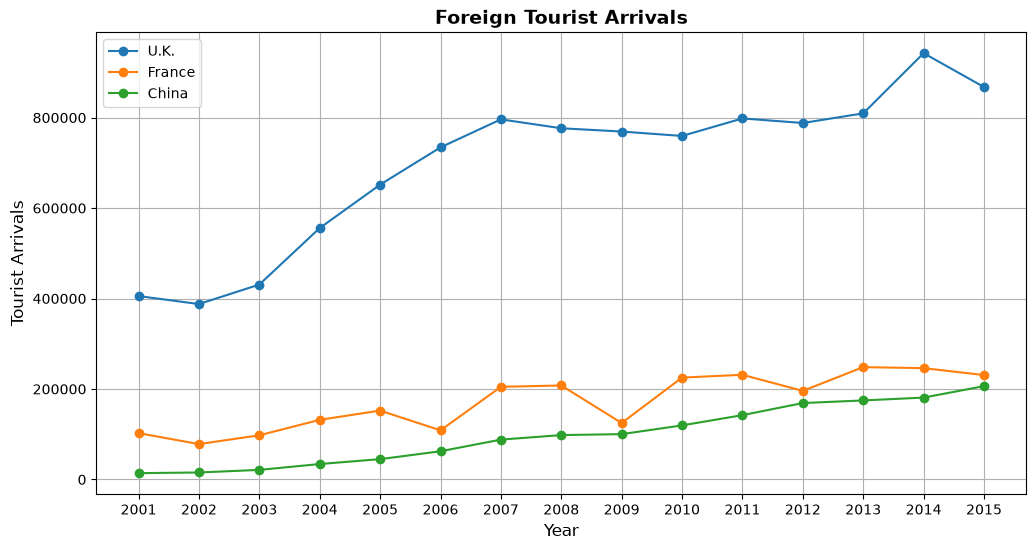

In [74]:
plt.figure(figsize=(12, 6))
# Lets plot a few sample countries
for index, row in df.head(3).iterrows():
    country_name = row['Name of Countries']
    # Extract the year values for this country
    arrivals = row[year_cols].values
    # Plot the trend line
    plt.plot(year_cols, arrivals, marker='o', label=country_name)

# Add titles
plt.title('Foreign Tourist Arrivals', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Tourist Arrivals', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

In [75]:
# melt the dataframe to convert year columns into rows
df_melted = df.melt(
    id_vars=['Name of Countries'], 
    value_vars=year_cols, 
    var_name='Year', 
    value_name='Tourist_Arrivals'
)

In [76]:
# Convert year back to integer so models can process it
df_melted['Year'] = df_melted['Year'].astype(int)

In [79]:
df_melted.head(100)

,Name of Countries,Year,Tourist_Arrivals
0,U.K.,2001,405472.0
1,France,2001,102434.0
2,China,2001,13901.0
3,Italy,2001,68940.0
4,Bangladesh,2001,431312.0
...,...,...,...
95,U.K.,2006,734240.0
96,France,2006,108576.5
97,China,2006,62330.0
98,Italy,2006,79978.0


In [80]:
df_melted.info()

<class 'pandas.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name of Countries  285 non-null    str    
 1   Year               285 non-null    int64  
 2   Tourist_Arrivals   285 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 6.8 KB


df_melted.to_csv("cleaned tourist dataset.csv" , index= False)